In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Carreguem
df = pd.read_csv('../data/processed/df_features.csv')
y  = pd.read_csv('../data/processed/y.csv').squeeze()

# Separem train i test
train = df.iloc[:len(y)]
test  = df.iloc[len(y):]

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Target: {y.shape}")

Train: (1458, 255)
Test:  (1459, 255)
Target: (1458,)


In [2]:
# Escalem — Ridge necessita features a la mateixa escala
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)

# Cross-validation amb 5 folds
ridge = Ridge(alpha=10)
scores = cross_val_score(ridge, train_scaled, y, 
                         cv=5, scoring='neg_root_mean_squared_error')

print(f"Ridge CV log-RMSE: {-scores.mean():.4f} ± {scores.std():.4f}")

Ridge CV log-RMSE: 0.1018 ± 0.0063


In [3]:
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, 
                               random_state=42)
scores_xgb = cross_val_score(xgb_model, train, y,
                              cv=5, scoring='neg_root_mean_squared_error')

print(f"XGBoost CV log-RMSE: {-scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

XGBoost CV log-RMSE: 0.1062 ± 0.0032


In [4]:
from sklearn.model_selection import GridSearchCV

alphas = [0.1, 1, 5, 10, 50, 100, 300, 500]
ridge_grid = GridSearchCV(Ridge(), {'alpha': alphas}, 
                          cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(train_scaled, y)

print(f"Ridge millor alpha: {ridge_grid.best_params_}")
print(f"Ridge millor CV log-RMSE: {-ridge_grid.best_score_:.4f}")

Ridge millor alpha: {'alpha': 10}
Ridge millor CV log-RMSE: 0.1018


In [5]:
xgb_tuned = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

scores_xgb_tuned = cross_val_score(xgb_tuned, train, y,
                                    cv=5, scoring='neg_root_mean_squared_error')

print(f"XGBoost tuned CV log-RMSE: {-scores_xgb_tuned.mean():.4f} ± {scores_xgb_tuned.std():.4f}")

XGBoost tuned CV log-RMSE: 0.0973 ± 0.0046


In [6]:
# Ridge — entrenem amb totes les dades de train
ridge_final = Ridge(alpha=300)
ridge_final.fit(train_scaled, y)
pred_ridge_train = ridge_final.predict(train_scaled)
pred_ridge_test  = ridge_final.predict(test_scaled)

# XGBoost — entrenem amb totes les dades de train
xgb_final = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.01,
    max_depth=4, min_child_weight=2,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(train, y)
pred_xgb_train = xgb_final.predict(train)
pred_xgb_test  = xgb_final.predict(test)

print("Models entrenats!")

Models entrenats!


In [7]:
# Blend — mitjana ponderada de les dues prediccions
# Donem més pes a XGBoost perquè té millor CV score
blend_train = 0.4 * pred_ridge_train + 0.6 * pred_xgb_train
blend_test  = 0.4 * pred_ridge_test  + 0.6 * pred_xgb_test

# Avaluem el blend al train
from sklearn.metrics import mean_squared_error
rmse_blend = np.sqrt(mean_squared_error(y, blend_train))
print(f"Blend log-RMSE train: {rmse_blend:.4f}")

# Comparem els tres

print(f"Blend train: {rmse_blend:.4f}")

Blend log-RMSE train: 0.0531
Blend train: 0.0531


In [8]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train):
    # Split
    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Ridge
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    # XGBoost
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    # Blend
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)


print(f"\nResum:")
print(f"Ridge    CV: {-ridge_grid.best_score_:.4f}")
print(f"XGBoost  CV: {-scores_xgb_tuned.mean():.4f} ± {scores_xgb_tuned.std():.4f}")
print(f"Blend    CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")


Resum:
Ridge    CV: 0.1018
XGBoost  CV: 0.0973 ± 0.0046
Blend    CV: 0.0945 ± 0.0056


In [9]:
df = df.copy()
df.to_csv('../data/processed/df_features.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)
print(f"Dataset guardat! Shape: {df.shape}")

Dataset guardat! Shape: (2917, 255)


In [10]:
print(f"y shape: {y.shape}")
print(f"y valors: {y.head()}")

y shape: (1458,)
y valors: 0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64


In [11]:
print(f"df shape: {df.shape}")
print(f"y shape: {len(y)}")
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

df shape: (2917, 255)
y shape: 1458
train shape: (1458, 255)
test shape: (1459, 255)


In [12]:
# Desfer el log1p per obtenir preus reals
submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)

submission.to_csv('../submissions/submission_02_blend.csv', index=False)
print("Submission guardada!")
print(submission.head())

Submission guardada!
     Id      SalePrice
0  1461  120034.531458
1  1462  162977.505052
2  1463  182793.764266
3  1464  196744.750350
4  1465  183597.774215


In [13]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

scores_lgb = cross_val_score(lgb_model, train, y,
                              cv=5, scoring='neg_root_mean_squared_error')

print(f"LightGBM CV log-RMSE: {-scores_lgb.mean():.4f} ± {scores_lgb.std():.4f}")

LightGBM CV log-RMSE: 0.1039 ± 0.0031


In [14]:
lgb_fast = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbose=-1
)

scores_lgb_fast = cross_val_score(lgb_fast, train, y,
                                   cv=5, scoring='neg_root_mean_squared_error')
print(f"LightGBM fast CV log-RMSE: {-scores_lgb_fast.mean():.4f} ± {scores_lgb_fast.std():.4f}")

LightGBM fast CV log-RMSE: 0.1054 ± 0.0034


In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train):
    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Ridge
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    # XGBoost
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    # LightGBM
    lgb_fast.fit(X_tr, y_tr)
    p_lgb = lgb_fast.predict(X_val)
    
    # Blend 3 models
    p_blend = 0.3 * p_ridge + 0.5 * p_xgb + 0.2 * p_lgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend 3 models CV log-RMSE: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend 3 models CV log-RMSE: 0.0951 ± 0.0058


In [16]:
# Quines cases prediu pitjor?
ridge_final.fit(train_scaled, y)
pred_train = ridge_final.predict(train_scaled)
residuals = y - pred_train

# Cases amb error més gran
error_df = pd.DataFrame({
    'real': np.expm1(y),
    'predit': np.expm1(pred_train),
    'error': np.abs(residuals)
}).sort_values('error', ascending=False)

print(error_df.head(10))

          real         predit     error
631    82500.0  147831.728682  0.583271
462    62383.0  104371.623079  0.514659
1322  147000.0  232579.298090  0.458796
495    34900.0   53051.235717  0.418762
1430   64500.0   97586.108232  0.414065
532    39300.0   59385.986598  0.412825
30     40000.0   60221.291537  0.409138
967    37900.0   56284.868943  0.395466
969   135000.0   91667.563145  0.387103
709    52000.0   73779.376541  0.349830


In [17]:
# Analitzem les cases amb més error
error_idx = error_df.head(18).index

train_original = pd.read_csv('../data/raw/train.csv')
train_original.iloc[error_idx][['SalePrice', 'Neighborhood', 'SaleCondition', 
                                 'OverallQual', 'GrLivArea', 'YearBuilt']]

,SalePrice,Neighborhood,SaleCondition,OverallQual,GrLivArea,YearBuilt
631,209500,NridgHt,Normal,8,1554,2006
462,62383,Sawyer,Normal,5,864,1965
1322,190000,NoRidge,Normal,7,1923,1992
495,34900,IDOTRR,Abnorml,4,720,1920
1430,192140,Gilbert,Normal,5,1838,2005
532,107500,NAmes,Normal,5,827,1955
30,40000,IDOTRR,Normal,4,1317,1920
967,135000,NAmes,Normal,5,1098,1955
969,140000,NAmes,Normal,6,1095,1958
709,109900,Sawyer,Abnorml,5,904,1966


In [18]:
print(f"Cases mal avaluades (error > 0.3): {(np.abs(residuals) > 0.3).sum()}")
print(f"Total cases train: {len(train)}")
print(f"Percentatge: {(np.abs(residuals) > 0.3).mean()*100:.1f}%")

Cases mal avaluades (error > 0.3): 12
Total cases train: 1458
Percentatge: 0.8%


In [19]:
# Llindar 15% en escala log
llindar = np.log1p(1.15) - np.log1p(1)
print(f"Llindar log equivalent al 15%: {llindar:.3f}")

print(f"\nError > 15%: {(np.abs(residuals) > llindar).sum()} cases ({(np.abs(residuals) > llindar).mean()*100:.1f}%)")

Llindar log equivalent al 15%: 0.072

Error > 15%: 480 cases (32.9%)


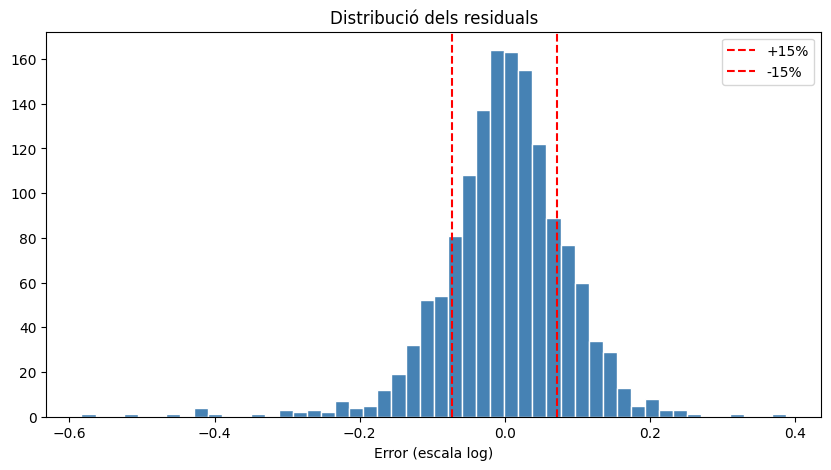

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=llindar, color='red', linestyle='--', label='+15%')
plt.axvline(x=-llindar, color='red', linestyle='--', label='-15%')
plt.title('Distribució dels residuals')
plt.xlabel('Error (escala log)')
plt.legend()
plt.show()

In [21]:
print(f"test shape: {test.shape}")
print(f"blend_test shape: {len(blend_test)}")

test shape: (1459, 255)
blend_test shape: 1459


In [22]:
import matplotlib.pyplot as plt

# Feature importance de XGBoost
xgb_final.fit(train, y)
importance = pd.Series(xgb_final.feature_importances_, index=train.columns)
importance = importance.sort_values(ascending=False)

# Top 20 i bottom 20
print("\nBOTTOM 20 — candidates a eliminar:")
print(importance.tail(20))


BOTTOM 20 — candidates a eliminar:
Electrical_Mix          0.0
Electrical_FuseP        0.0
Street_Pave             0.0
Fence_MnWw              0.0
Heating_OthW            0.0
MiscFeature_Gar2        0.0
Heating_Floor           0.0
MiscFeature_Othr        0.0
Exterior2nd_Other       0.0
MiscFeature_TenC        0.0
Exterior2nd_CBlock      0.0
SaleType_CWD            0.0
SaleType_Con            0.0
SaleType_ConLD          0.0
Exterior2nd_Brk Cmn     0.0
Exterior1st_WdShing     0.0
Exterior1st_Stone       0.0
SaleType_Oth            0.0
Exterior1st_ImStucc     0.0
Neighborhood_Blueste    0.0
dtype: float32


In [23]:
zero_importance = importance[importance == 0]
print(f"Features amb importància 0: {len(zero_importance)}")
print(f"Total features: {len(importance)}")

Features amb importància 0: 46
Total features: 255


In [24]:
# Eliminem features amb importància 0
cols_to_drop = zero_importance.index.tolist()
train_reduced = train.drop(cols_to_drop, axis=1)
test_reduced  = test.drop(cols_to_drop, axis=1)

print(f"Features abans: {train.shape[1]}")
print(f"Features després: {train_reduced.shape[1]}")

# CV amb XGBoost reduït
scores_reduced = cross_val_score(xgb_final, train_reduced, y,
                                  cv=5, scoring='neg_root_mean_squared_error')
print(f"XGBoost reduït CV: {-scores_reduced.mean():.4f} ± {scores_reduced.std():.4f}")

Features abans: 255
Features després: 209
XGBoost reduït CV: 0.0972 ± 0.0043


In [25]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train_reduced):
    X_tr, X_val = train_reduced.iloc[train_idx], train_reduced.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend reduït CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend reduït CV: 0.0941 ± 0.0052


In [26]:
# Entrenem amb totes les dades reduïdes
ridge_final.fit(scaler.fit_transform(train_reduced), y)
xgb_final.fit(train_reduced, y)

pred_ridge = ridge_final.predict(scaler.transform(test_reduced))
pred_xgb   = xgb_final.predict(test_reduced)

blend_test = 0.4 * pred_ridge + 0.6 * pred_xgb

submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)
submission.to_csv('../submissions/submission_02_blend_reduced.csv', index=False)
print("Submission guardada!")

Submission guardada!


In [27]:
low_importance = importance[importance < 0.001]
print(f"Features amb importància < 0.001: {len(low_importance)}")
print(low_importance.sort_values())

Features amb importància < 0.001: 145
Neighborhood_Blueste    0.000000
Condition1_RRNe         0.000000
Condition1_RRNn         0.000000
Condition2_Artery       0.000000
Condition2_PosA         0.000000
                          ...   
Neighborhood_Mitchel    0.000945
Condition2_Norm         0.000951
Neighborhood_NWAmes     0.000953
Condition1_Artery       0.000986
Foundation_CBlock       0.000986
Length: 145, dtype: float32


In [28]:
for llindar in [0.001, 0.002, 0.005, 0.01]:
    n = (importance < llindar).sum()
    print(f"< {llindar}: {n} features a eliminar → {249-n} restants")

< 0.001: 145 features a eliminar → 104 restants
< 0.002: 202 features a eliminar → 47 restants
< 0.005: 231 features a eliminar → 18 restants
< 0.01: 241 features a eliminar → 8 restants


In [29]:
for llindar in [0.001, 0.002, 0.005, 0.01]:
    cols_keep = importance[importance >= llindar].index.tolist()
    X_red = train[cols_keep]
    
    scores = cross_val_score(xgb_final, X_red, y,
                             cv=5, scoring='neg_root_mean_squared_error')
    print(f"Llindar {llindar} ({len(cols_keep)} features): CV {-scores.mean():.4f} ± {scores.std():.4f}")

Llindar 0.001 (110 features): CV 0.0969 ± 0.0047
Llindar 0.002 (53 features): CV 0.0961 ± 0.0050
Llindar 0.005 (24 features): CV 0.1032 ± 0.0050
Llindar 0.01 (14 features): CV 0.1056 ± 0.0067


In [30]:
cols_keep = importance[importance >= 0.001].index.tolist()
train_reduced2 = train[cols_keep]
test_reduced2  = test[cols_keep]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train_reduced2):
    X_tr, X_val = train_reduced2.iloc[train_idx], train_reduced2.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend 110 features CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend 110 features CV: 0.0937 ± 0.0053


In [31]:
ridge_final.fit(scaler.fit_transform(train_reduced2), y)
xgb_final.fit(train_reduced2, y)

pred_ridge = ridge_final.predict(scaler.transform(test_reduced2))
pred_xgb   = xgb_final.predict(test_reduced2)

blend_test = 0.4 * pred_ridge + 0.6 * pred_xgb

submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)
submission.to_csv('../submissions/submission_03_110features.csv', index=False)
print("Submission guardada!")

Submission guardada!


In [32]:
from sklearn.model_selection import GridSearchCV

xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

params = {
    'reg_alpha':  [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5, 10],
}

grid = GridSearchCV(xgb_reg, params, cv=5, 
                    scoring='neg_root_mean_squared_error')
grid.fit(train_reduced, y)

print(f"Millors params: {grid.best_params_}")
print(f"Millor CV: {-grid.best_score_:.4f}")

Millors params: {'reg_alpha': 0, 'reg_lambda': 1}
Millor CV: 0.0985


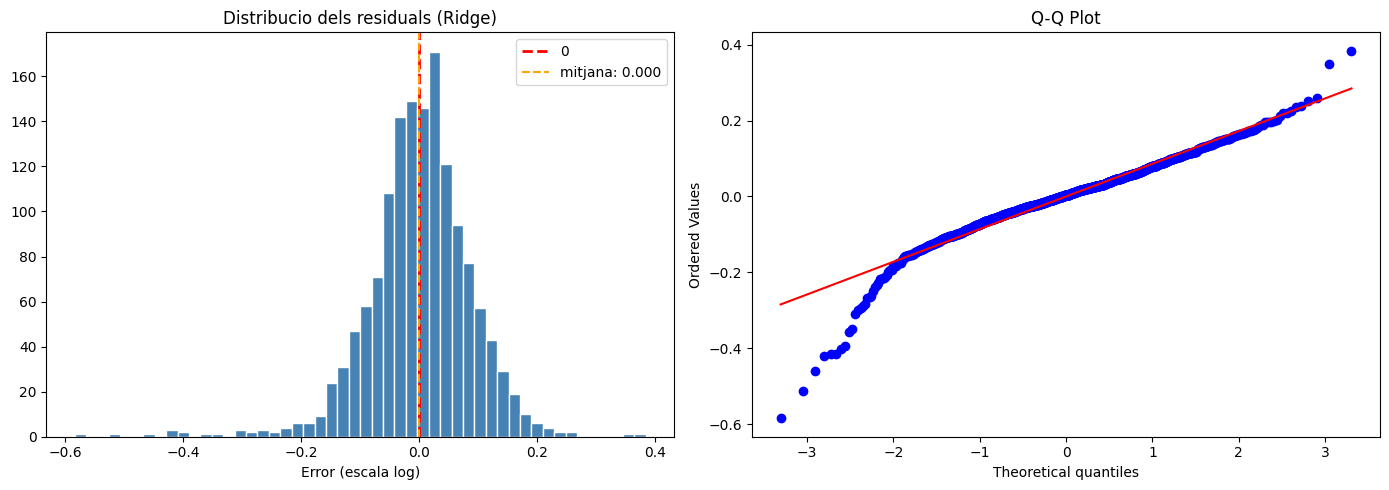

Mitjana residuals: 0.0000
Std residuals:     0.0882
Skewness:          -0.8608


In [33]:
# Entrenem Ridge amb totes les dades per obtenir residuals
ridge_final.fit(scaler.fit_transform(train_reduced), y)
pred_train = ridge_final.predict(scaler.transform(train_reduced))
residuals = y - pred_train

# Campana de Gauss dels residuals
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1.hist(residuals, bins=50, color='steelblue', edgecolor='white')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0')
ax1.axvline(x=residuals.mean(), color='orange', linestyle='--', label=f'mitjana: {residuals.mean():.3f}')
ax1.set_title('Distribucio dels residuals (Ridge)')
ax1.set_xlabel('Error (escala log)')
ax1.legend()

# Q-Q plot — com de normal es la distribucio
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Mitjana residuals: {residuals.mean():.4f}")
print(f"Std residuals:     {residuals.std():.4f}")
print(f"Skewness:          {residuals.skew():.4f}")

In [34]:
print(type(ridge_final))
print(train_reduced.shape)

<class 'sklearn.linear_model._ridge.Ridge'>
(1458, 209)


Ridge: mitjana=0.0000 | std=0.0882 | skew=-0.8608
XGBoost: mitjana=0.0000 | std=0.0375 | skew=-0.4591
Blend: mitjana=0.0000 | std=0.0538 | skew=-0.6801


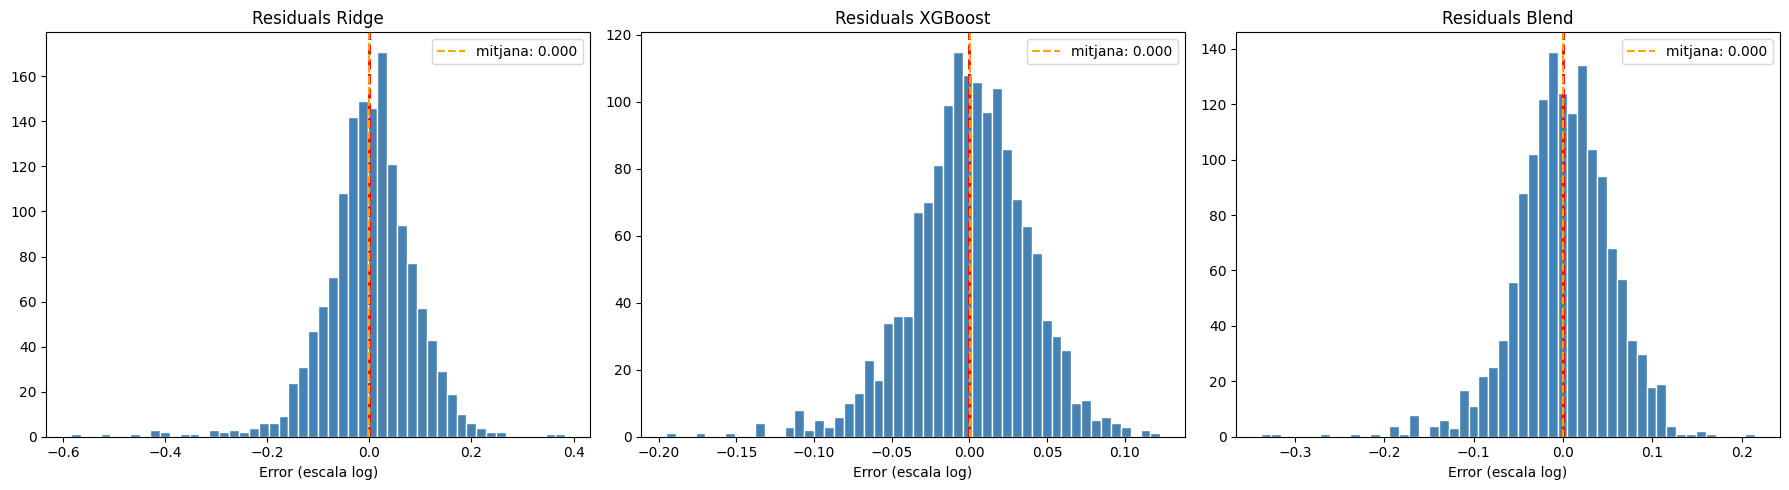

In [35]:
# Entrenem els tres models
ridge_final.fit(scaler.fit_transform(train_reduced), y)
xgb_final.fit(train_reduced, y)

pred_ridge = ridge_final.predict(scaler.transform(train_reduced))
pred_xgb   = xgb_final.predict(train_reduced)
pred_blend = 0.4 * pred_ridge + 0.6 * pred_xgb

residuals_ridge = y - pred_ridge
residuals_xgb   = y - pred_xgb
residuals_blend = y - pred_blend

# Campanes dels tres
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, nom in zip(axes, 
                         [residuals_ridge, residuals_xgb, residuals_blend],
                         ['Ridge', 'XGBoost', 'Blend']):
    ax.hist(res, bins=50, color='steelblue', edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.axvline(x=res.mean(), color='orange', linestyle='--', label=f'mitjana: {res.mean():.3f}')
    ax.set_title(f'Residuals {nom}')
    ax.set_xlabel('Error (escala log)')
    ax.legend()
    print(f"{nom}: mitjana={res.mean():.4f} | std={res.std():.4f} | skew={res.skew():.4f}")

plt.tight_layout()
plt.show()

In [36]:
scores_xgb_solo = cross_val_score(xgb_final, train_reduced, y,
                                   cv=5, scoring='neg_root_mean_squared_error')
print(f"XGBoost sol CV: {-scores_xgb_solo.mean():.4f} ± {scores_xgb_solo.std():.4f}")

XGBoost sol CV: 0.0972 ± 0.0043


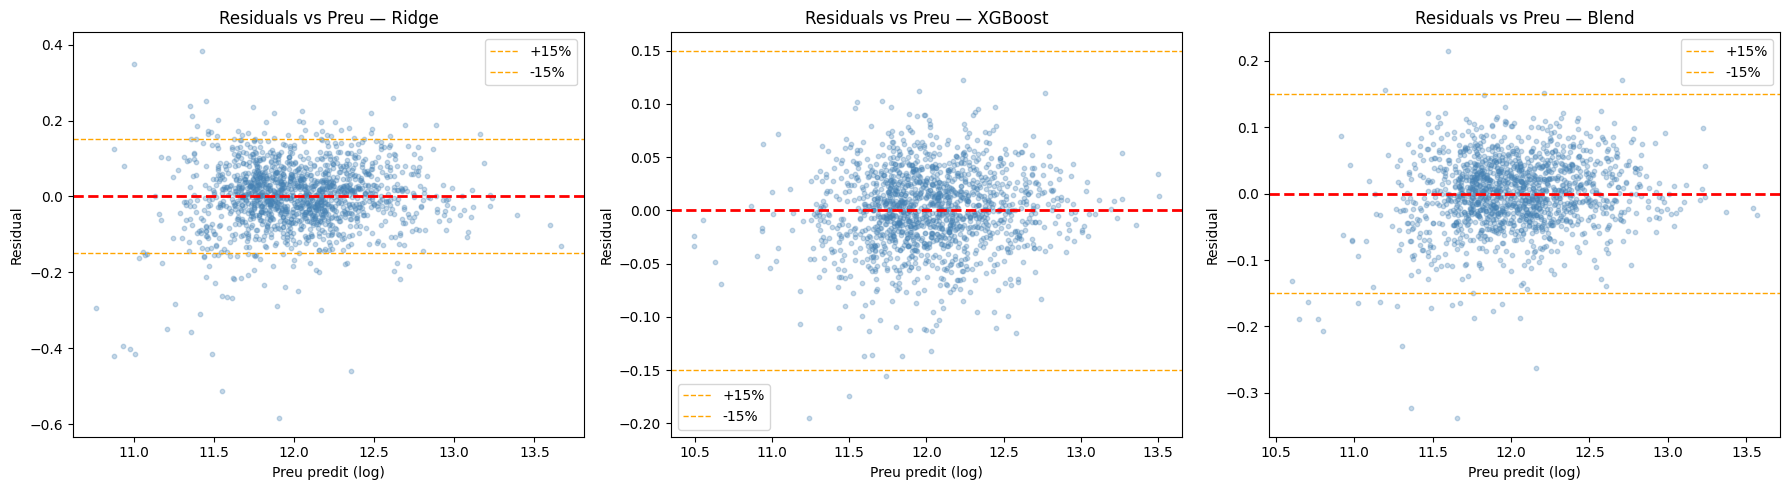

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, pred, nom in zip(axes,
                               [residuals_ridge, residuals_xgb, residuals_blend],
                               [pred_ridge, pred_xgb, pred_blend],
                               ['Ridge', 'XGBoost', 'Blend']):
    ax.scatter(pred, res, alpha=0.3, color='steelblue', s=10)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.axhline(y=0.15, color='orange', linestyle='--', linewidth=1, label='+15%')
    ax.axhline(y=-0.15, color='orange', linestyle='--', linewidth=1, label='-15%')
    ax.set_xlabel('Preu predit (log)')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals vs Preu — {nom}')
    ax.legend()

plt.tight_layout()
plt.show()

In [38]:
# On es concentren els errors d'XGBoost?
error_xgb = pd.DataFrame({
    'preu_predit': np.expm1(pred_xgb),
    'residual': residuals_xgb,
    'error_abs': np.abs(residuals_xgb)
})

# Per rangs de preu
bins = [0, 100000, 150000, 200000, 300000, 500000, 9999999]
labels = ['<100k', '100-150k', '150-200k', '200-300k', '300-500k', '>500k']
error_xgb['rang'] = pd.cut(error_xgb['preu_predit'], bins=bins, labels=labels)

print(error_xgb.groupby('rang')['error_abs'].mean().sort_values(ascending=False))

rang
<100k       0.034038
200-300k    0.029320
100-150k    0.028503
150-200k    0.028276
300-500k    0.023795
>500k       0.017960
Name: error_abs, dtype: float64


In [40]:
print(train.shape)

(1458, 255)


In [ ]:
# ZonaCon al train — usa preus reals, pot ser leakage!
print(df['ZonaCon'].value_counts())
print(f"\nZonaCon correlació amb y: {df.iloc[:len(y)]['ZonaCon'].corr(y):.3f}")